📊 Data Cleaning: Handling Missing Values & Outliers

Dataset: Hotel Booking Demand
Objective:

Handle missing values

Detect and treat outliers



1️⃣ Import Libraries & Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv('hotel_bookings.csv')

In [23]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


2️⃣ Basic Data Inspection

In [25]:
df.shape

(119390, 32)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [29]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## Observations from Statistical Summary

From the statistical summary of the dataset, the following data quality issues were identified:

1. The `children` column has missing values (count < total rows).
2. The `agent` and `company` columns have a large number of missing values.
3. The `adr` column contains negative values and extremely high values, indicating the presence of outliers.
4. Columns such as `lead_time`, `stays_in_week_nights`, and `adults` show unusually large maximum values, suggesting potential outliers.

These issues must be addressed to ensure reliable analysis and modeling.

## 3. Detecting Missing Values

In [41]:
df.isna().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

## 3. Handling Missing Values


### 3.1 Handling missing values in `children`
Median is used as it is robust to outliers.

In [46]:
df['children'] = df['children'].fillna(df['children'].median())

### 3.2 Handling missing values in `country`
Mode is used for categorical features.

In [49]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

### 3.3 Handling missing values in `agent` and `company`
Missing values indicate no agent or no company.

In [54]:
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/4204442066.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(0, inplace=True)
/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/4204442066.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

In [56]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

## Outlier Detection and Treatment

### Detecting outliers in `adr` using boxplot

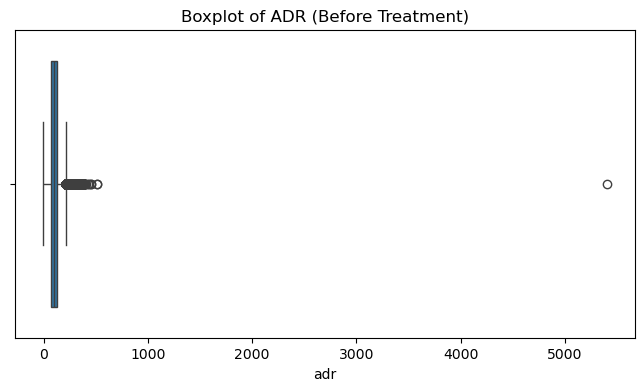

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df['adr'])
plt.title("Boxplot of ADR (Before Treatment)")
plt.show()

### Treating outliers using the IQR method

In [66]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [68]:
df['adr'] = np.where(df['adr'] < lower_bound, lower_bound, df['adr'])
df['adr'] = np.where(df['adr'] > upper_bound, upper_bound, df['adr'])

In [70]:
### ADR after outlier treatment

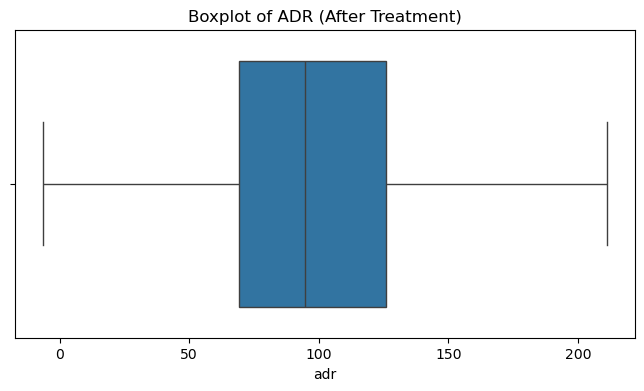

In [76]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['adr'])
plt.title("Boxplot of ADR (After Treatment)")
plt.show()

In [78]:
## Final Dataset Summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,74.828319,10.775157,2.321149,100.659305,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,107.141953,53.943884,17.594721,44.688946,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,152.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,211.065000,8.000000,5.000000


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Conclusion

Missing values were handled based on feature type and real-world meaning.
Outliers, especially in the `adr` column, were treated using the IQR method to reduce the impact of extreme values.
After cleaning, the dataset is consistent and suitable for further analysis or machine learning.

## Advanced Missing Value Handling Practice

In this section, different missing value imputation techniques are practiced
using separate copies of the same dataset for comparison.

In [89]:
df_base = df.copy()

A base copy of the dataset is created so that each imputation method
can be applied independently without affecting others.

In [92]:
import numpy as np

np.random.seed(42)

cols_to_add_nan = ['adr', 'lead_time', 'stays_in_week_nights']

for col in cols_to_add_nan:
    df_base.loc[df_base.sample(frac=0.1).index, col] = np.nan

In [94]:
df_base.isna().sum()

hotel                                 0
is_canceled                           0
lead_time                         11939
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights              11939
adults                                0
children                              0
babies                                0
meal                                  0
country                               0
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                                 0
company                               0


Artificial missing values are introduced to simulate real-world data issues
and to practice advanced imputation techniques.

## Method 1: Mean Imputation

In [100]:
df_mean = df_base.copy()

In [104]:
df_mean['adr'].fillna(df_mean['adr'].mean(), inplace=True)
df_mean['lead_time'].fillna(df_mean['lead_time'].mean(), inplace=True)
df_mean['stays_in_week_nights'].fillna(df_mean['stays_in_week_nights'].mean(), inplace=True)

/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/2187187255.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['adr'].fillna(df_mean['adr'].mean(), inplace=True)
/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/2187187255.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [106]:
df_mean.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

Mean imputation is simple and fast but is sensitive to outliers.

===============================
METHOD 2: MEDIAN IMPUTATION
===============================

In [114]:
df_median = df_base.copy()

In [116]:
df_median['adr'].fillna(df_median['adr'].median(), inplace=True)
df_median['lead_time'].fillna(df_median['lead_time'].median(), inplace=True)
df_median['stays_in_week_nights'].fillna(df_median['stays_in_week_nights'].median(), inplace=True)

/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/816675498.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median['adr'].fillna(df_median['adr'].median(), inplace=True)
/var/folders/t1/8ycmz7_s3jn7zvgt98_hcc0c0000gn/T/ipykernel_89658/816675498.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [118]:
df_median.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

===============================
METHOD 3: KNN IMPUTATION
===============================

In [123]:
from sklearn.impute import KNNImputer

In [125]:
df_knn = df_base.copy()

knn_cols = ['adr', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights']

knn_imputer = KNNImputer(n_neighbors=5)
df_knn[knn_cols] = knn_imputer.fit_transform(df_knn[knn_cols])

In [127]:
df_knn[knn_cols].isna().sum()

adr                        0
lead_time                  0
stays_in_week_nights       0
stays_in_weekend_nights    0
dtype: int64

KNN imputation fills missing values using similar records based on distance.

===============================
METHOD 4: ITERATIVE IMPUTER (MICE)
===============================

In [134]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [140]:
df_iter = df_base.copy()

iter_cols = ['adr', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights']

iter_imputer = IterativeImputer(random_state=42)
df_iter[iter_cols] = iter_imputer.fit_transform(df_iter[iter_cols])

In [142]:
df_iter[iter_cols].isna().sum()

adr                        0
lead_time                  0
stays_in_week_nights       0
stays_in_weekend_nights    0
dtype: int64

In [144]:
Iterative imputation predicts missing values using other features in a round-robin manner.

SyntaxError: invalid syntax (2256181325.py, line 1)

## Summary of Missing Value Techniques Practiced

| Method | Use Case |
|------|---------|
| Mean | Fast baseline |
| Median | Robust to outliers |
| Mode | Categorical data |
| KNN | Similarity-based |
| Iterative | Multivariate relationships |
| Constant | Meaningful absence |
| Indicator | Model awareness |